In [1]:
import json
import os
try:
    from backend.utils import load_json
except ModuleNotFoundError:
    print("Updating working directory....")
    os.chdir("../")
    print(os.getcwd())
    from backend.utils import load_json
    
from tqdm import tqdm 
from backend.utils import load_response_dict
from backend.dataset_utils import organize_dataset
from backend.nli_labels import ExNLILabel
import math

import matplotlib.pyplot as plt
import numpy as np

from backend.uncertainty.utils import remove_invalid, calculate_probs, find_relevant_logprobs, sort_correct_wrong
from backend.uncertainty.metrics import calculate_uncertainty
import itertools

Updating working directory....
/home/baratovfs/repos/contractnli-llms


In [15]:
# load dataset
dataset = load_json("data/test.json")
dataset = organize_dataset(dataset)

response_dirs = {
    "Qwen3 30B": [[
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/qwen3_30b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "Gemma3 27B": [[
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gemma3_27b/narendra_nli_nonbinary/seed42"
    ], "classification"],
    "GPT-OSS 20B": [[
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/gpt-oss_20b/narendra_nli_nonbinary/seed42"
    ], None],
    "LLaMA3.1 8B": [[
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed0",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed1",
        "out/responses/config_1/llama3.1_8b/narendra_nli_nonbinary/seed42"
    ], "classification"]
}

    # load and process responses

model_responses = {}
by_seed = {}
for model, (response_dir, structure) in response_dirs.items():
    by_seed[model] = {}
    correct, wrong = {}, {}
    for fp in response_dir:
        try:
            responses = load_response_dict(fp)
        except FileNotFoundError:
            continue
        remove_invalid(responses)

        # add probabilities to responses
        # calculate_probs(responses)
        find_relevant_logprobs(responses, relevant_scope=None, structure=structure)
        calculate_uncertainty(responses)

        # find correct/wrong
        c, w = sort_correct_wrong(dataset, responses)

        # complicated indexing to save on boilerplating 
        for big_dict, sub_dict in [(correct, c), (wrong, w)]:
            if len(big_dict) == 0:
                for k,v in sub_dict.items():
                    big_dict[k] = v
            else:
                for k,v in big_dict.items():
                    big_dict[k] = v + sub_dict[k]
        
        seed = int(fp.split("/")[-1][4:])
        by_seed[model][seed] = {
            "correct": c,
            "wrong": w
        }
    
    model_responses[model] = {
        "correct": correct,
        "wrong": wrong
    }

Loading responses: 100%|██████████| 123/123 [01:11<00:00,  1.71it/s]


Removed 3 invalid answers!


Probabilities:  17%|█▋        | 21/123 [00:02<00:11,  8.99it/s]/home/baratovfs/repos/contractnli-llms/backend/uncertainty/metrics.py:14: RuntimeWarning: overflow encountered in exp
  return np.exp(average_logprob(logprobs))
Sorting: 100%|██████████| 123/123 [00:00<00:00, 31399.84it/s]


Num correct: 1536
Num wrong:   552


Loading responses: 100%|██████████| 123/123 [00:30<00:00,  4.00it/s]


...

Num correct: 1021
Num wrong:   1070


Loading responses: 100%|██████████| 123/123 [00:00<00:00, 159.39it/s]


Removed 0 invalid answers!


Sorting: 100%|██████████| 123/123 [00:00<00:00, 54621.43it/s]

Num correct: 959
Num wrong:   1132


In [16]:
def set_boxplot_line_color(bp, color):
    for element in ['boxes', 'whiskers', 'caps', 'medians']:
        for item in bp[element]:
            item.set_color(color)

def big_boxplot(correct: dict, wrong: dict, save_file: str, metric: str, title: str = ""):

    classes = sorted(list(correct.keys()))

    correct_data = []
    wrong_data = []
    for k in classes:
        correct_data.append(correct[k])
        wrong_data.append(wrong[k])

    num_groups = len(classes)
    positions = np.arange(num_groups)

    offset = 0.15
    width = 0.2
    
    fig = plt.figure(figsize=(10,7))
    ax = plt.gca()

    
    bp_correct = plt.boxplot(
        correct_data,
        positions=positions - offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    bp_wrong = plt.boxplot(
        wrong_data,
        positions=positions + offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    # Color the boxes
    set_boxplot_line_color(bp_correct, "blue")
    set_boxplot_line_color(bp_wrong, "red")

    # Axis formatting
    plt.xticks(positions, classes)
    plt.ylabel(metric)
    plt.legend(
        [bp_correct['boxes'][0], bp_wrong['boxes'][0]],
        ['Correct', 'Wrong']
    )
    
    ax.set_xlabel("Response prediction")
    ax.set_title(title)

    return ax, fig

    
# pick model
sorted_model_responses = {}
for k,v in model_responses.items():
    sorted_model_responses[k] = {}

    model_dict = model_responses[k]

    # sort correct/wrong properly, by class
    correct = {}
    wrong = {}
    for cw_dict, cw_str in [[correct, "correct"], [wrong, "wrong"]]:
        ld = model_dict[cw_str]
        for label in ld.keys():
            if label not in cw_dict:
                cw_dict[label] = []
            for el in ld[label]:
                cw_dict[label] += [el["uncertainty"]["perplexity"]]

        sorted_model_responses[k][cw_str] = cw_dict
    
# # plot graph
# ax, fig = boxplot_analysis(correct, wrong, metric="Perplexity", title=f"Perplexity for GPT-OSS 20B", save_file=None)
# fig.show()

In [17]:
def big_boxplot(correct: dict, wrong: dict, save_file: str, metric: str, title: str = ""):

    classes = sorted(list(correct.keys()))

    correct_data = []
    wrong_data = []
    for k in classes:
        correct_data.append(correct[k])
        wrong_data.append(wrong[k])

    num_groups = len(classes)
    positions = np.arange(num_groups)

    offset = 0.15
    width = 0.2
    
    fig = plt.figure(figsize=(10,7))
    ax = plt.gca()

    
    bp_correct = plt.boxplot(
        correct_data,
        positions=positions - offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    bp_wrong = plt.boxplot(
        wrong_data,
        positions=positions + offset,
        widths=width,
        patch_artist=False,
        showfliers=False
    )

    # Color the boxes
    set_boxplot_line_color(bp_correct, "blue")
    set_boxplot_line_color(bp_wrong, "red")

    # Axis formatting
    plt.xticks(positions, classes)
    plt.ylabel(metric)
    plt.legend(
        [bp_correct['boxes'][0], bp_wrong['boxes'][0]],
        ['Correct', 'Wrong']
    )
    
    ax.set_xlabel("Response prediction")
    ax.set_title(title)

    return ax, fig




In [18]:

def plot_model_grouped_boxplots(data):
    """
    Parameters
    ----------
    data : dict
        {
            "model1": {
                "correct": {"label1": [...], "label2": [...], "label3": [...]},
                "wrong":   {"label1": [...], "label2": [...], "label3": [...]}
            },
            "model2": { ... }
        }
    """

    models = list(data.keys())
    labels = list(next(iter(data.values()))['correct'].keys())

    num_labels = len(labels)
    box_width = 0.3
    pair_offset = 0.2
    model_gap = 1.0

    fig, ax = plt.subplots(figsize=(20,7))

    x_positions = []
    x_labels = []
    model_centers = []

    current_x = 0

    for model in models:
        model_start = current_x

        for label in labels:
            correct_vals = data[model]['correct'][label]
            wrong_vals = data[model]['wrong'][label]

            pos_correct = current_x - pair_offset
            pos_wrong = current_x + pair_offset

            bp_correct = ax.boxplot(
                correct_vals,
                positions=[pos_correct],
                widths=box_width,
                patch_artist=False,
                showfliers=False
            )
            bp_wrong = ax.boxplot(
                wrong_vals,
                positions=[pos_wrong],
                widths=box_width,
                patch_artist=False,
                showfliers=False
            )

            set_boxplot_line_color(bp_correct, 'blue')
            set_boxplot_line_color(bp_wrong, 'red')

            x_positions.append(current_x)
            x_labels.append(label)

            current_x += 1

        model_end = current_x - 1
        model_centers.append((model_start + model_end) / 2)
        current_x += model_gap

    # Label ticks for individual label pairs
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)

    # Model labels below x-axis
    for center, model in zip(model_centers, models):
        ax.text(
            center,
            -0.05,
            model,
            ha='center',
            va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=10,
            fontweight='bold'
        )

    ax.set_ylabel("Value")

    # Legend
    ax.plot([], [], color='blue', label='correct')
    ax.plot([], [], color='red', label='wrong')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

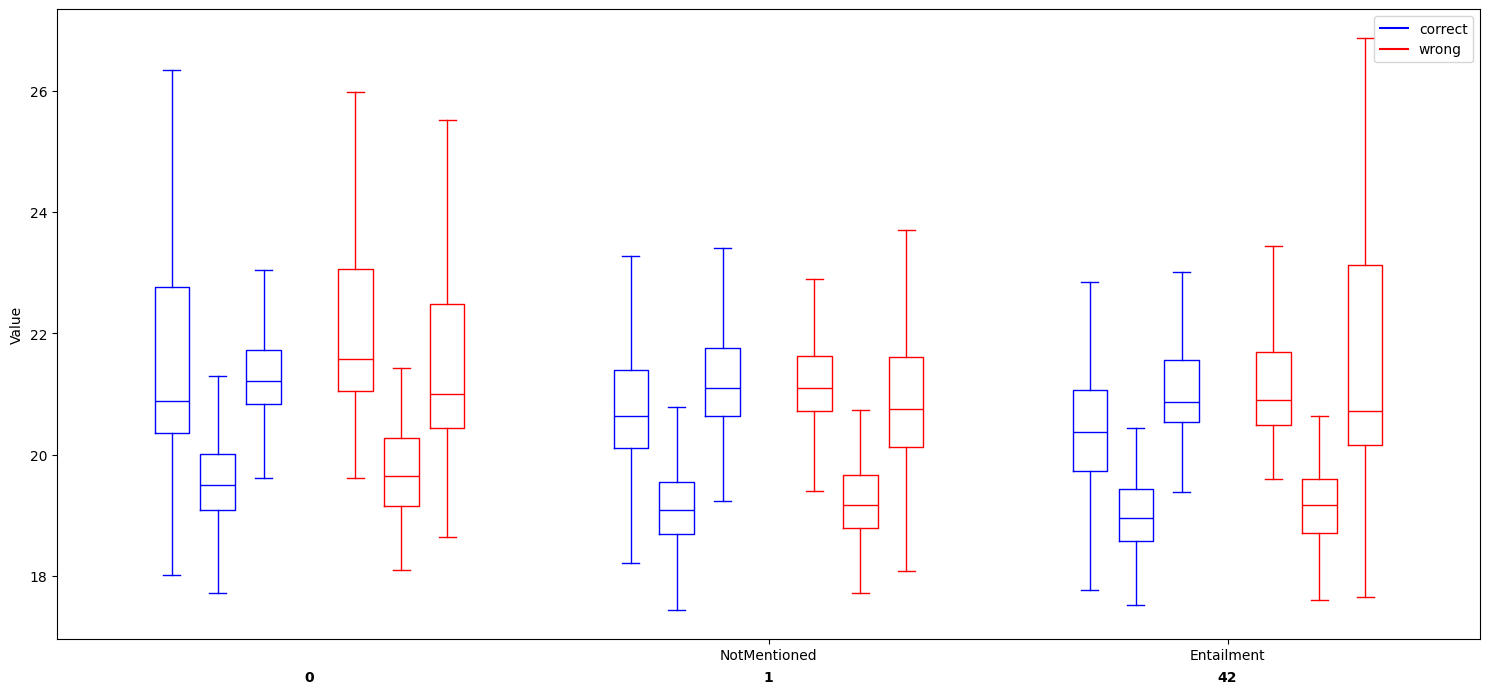

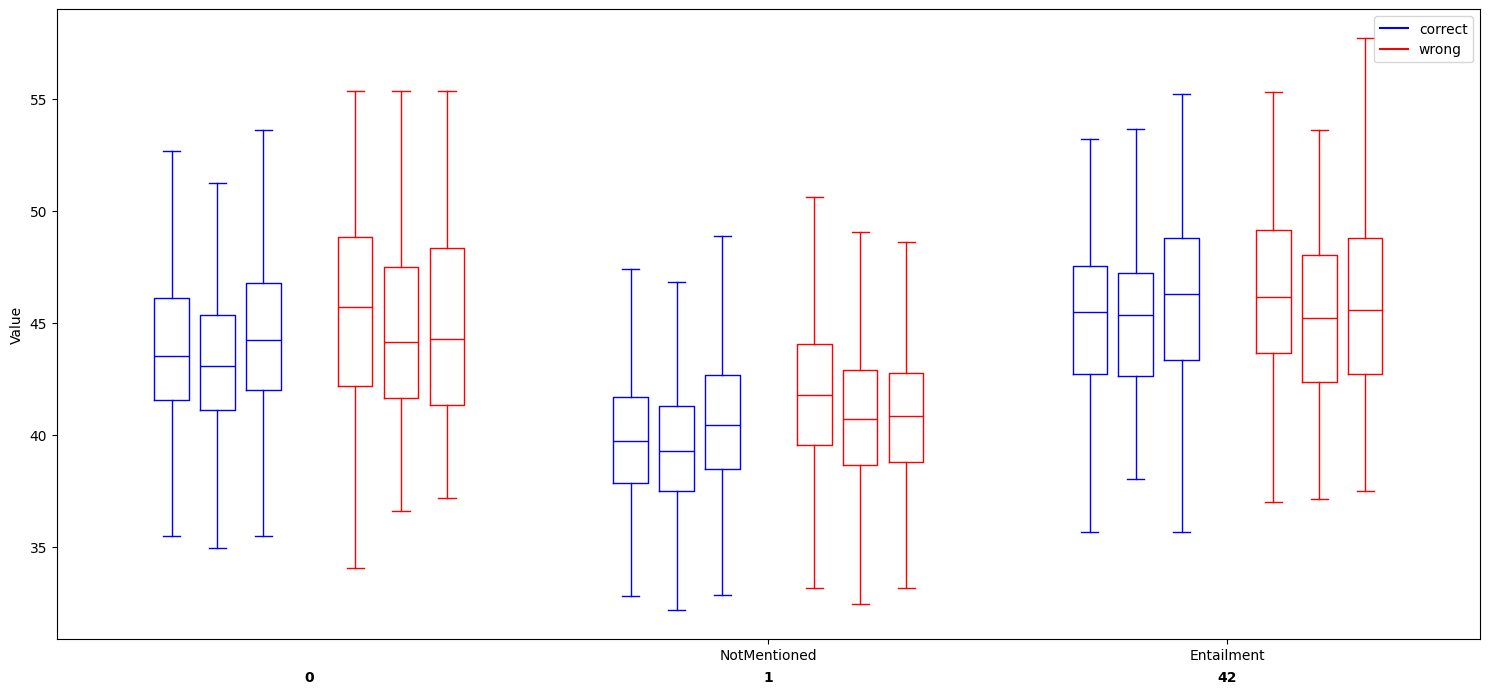

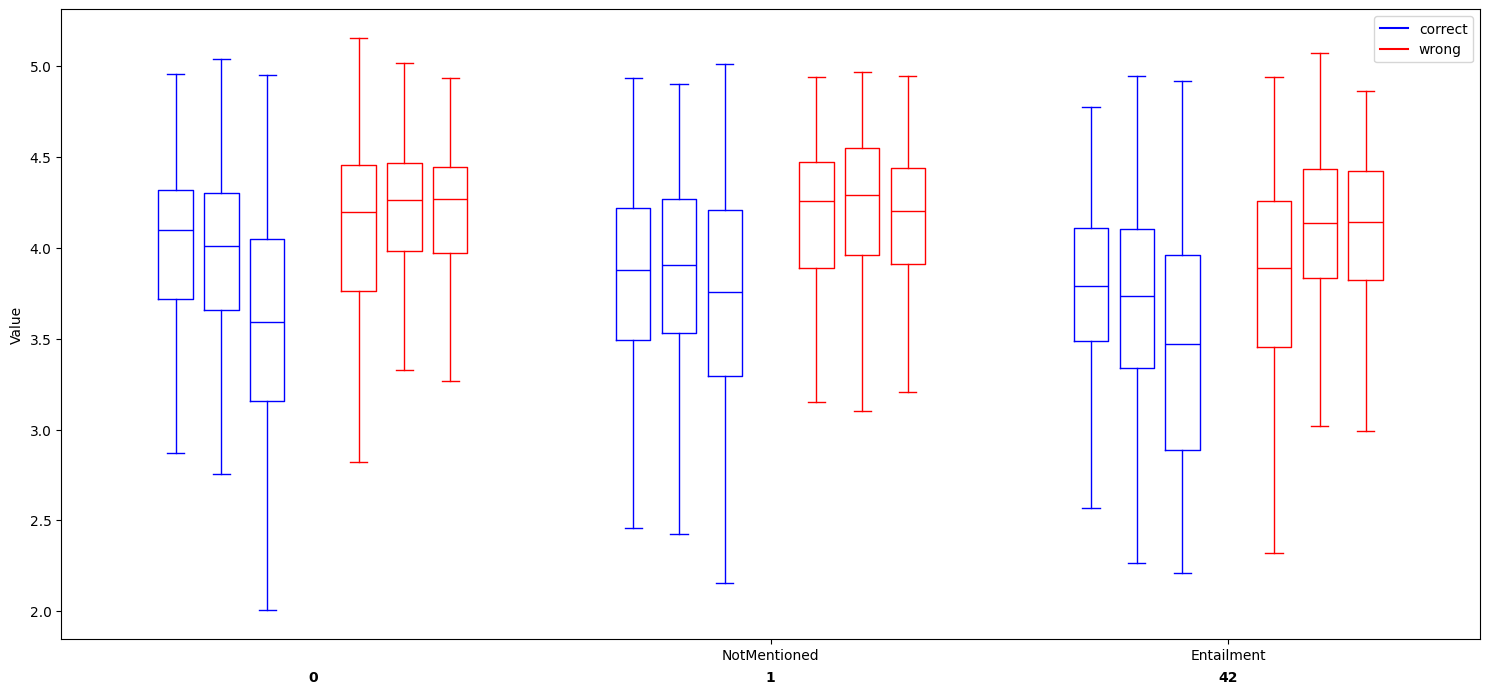

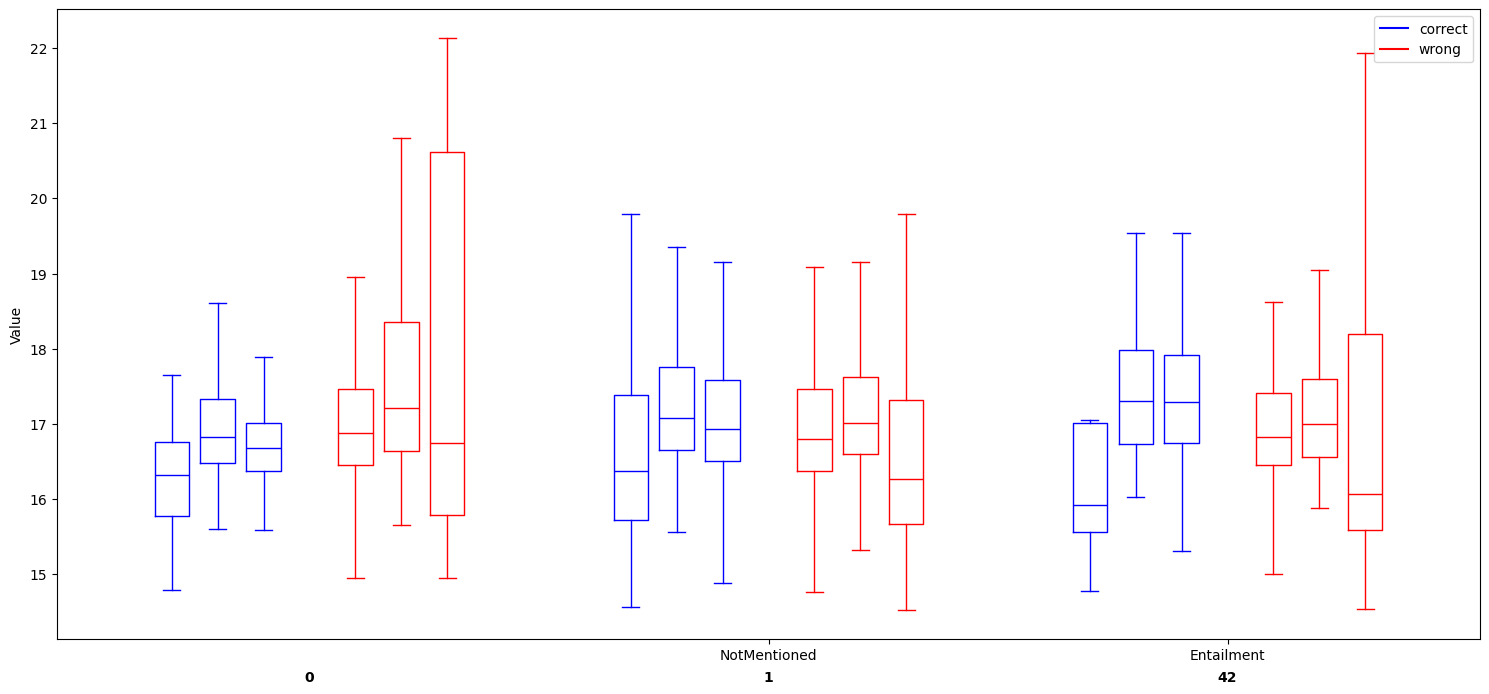

In [27]:
def plot_seed_boxplots(data):
    """
    Parameters
    ----------
    data : dict
        {
            "model1": {
                "correct": {"label1": [...], "label2": [...], "label3": [...]},
                "wrong":   {"label1": [...], "label2": [...], "label3": [...]}
            },
            "model2": { ... }
        }
    """

    seeds = list(data.keys())
    labels = list(next(iter(data.values()))['correct'].keys())

    num_labels = len(labels)
    box_width = 0.15
    pair_offset = [0.2, 0.4, 0.6]
    seed_gap = 1.0

    fig, ax = plt.subplots(figsize=(15,7))

    x_positions = []
    x_labels = []
    seed_centers = []

    current_x = 0

    for label in labels:
        
        model_start = current_x
        
        correct_vals = []
        wrong_vals = []
        for seed in seeds:
            correct_vals.append(data[seed]['correct'][label])
            wrong_vals.append(data[seed]['wrong'][label])

        pos_correct = [current_x - po for po in pair_offset]
        pos_wrong = [current_x + po for po in pair_offset]
        current_x += 1

        model_end = current_x - 1
        seed_centers.append((model_start + model_end) / 2)
        current_x += seed_gap


        bp_correct = ax.boxplot(
            correct_vals,
            positions=pos_correct,
            widths=box_width,
            patch_artist=False,
            showfliers=False,
        )
        bp_wrong = ax.boxplot(
            wrong_vals,
            positions=pos_wrong,
            widths=box_width,
            patch_artist=False,
            showfliers=False
        )

        set_boxplot_line_color(bp_correct, 'blue')
        set_boxplot_line_color(bp_wrong, 'red')

        x_positions.append(current_x)
        x_labels.append(label)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels)

    # Model labels below x-axis
    for center, seed in zip(seed_centers, seeds):
        ax.text(
            center,
            -0.05,
            seed,
            ha='center',
            va='top',
            transform=ax.get_xaxis_transform(),
            fontsize=10,
            fontweight='bold'
        )

    ax.set_ylabel("Value")

    # Legend
    ax.plot([], [], color='blue', label='correct')
    ax.plot([], [], color='red', label='wrong')
    ax.legend()

    plt.tight_layout()
    plt.show()

    return fig, ax

for metric in ["maximum_logprob"]:  
    sorted_seed_responses = {}
    for seed in by_seed.keys():
        for k,seed_dict in by_seed[seed].items():
            sorted_seed_responses[k] = {}


            # sort correct/wrong properly, by class
            correct = {}
            wrong = {}
            for cw_dict, cw_str in [[correct, "correct"], [wrong, "wrong"]]:
                # build cw dict
                ld = seed_dict[cw_str]
                for label in ld.keys():
                    if label not in cw_dict:
                        cw_dict[label] = []
                    for el in ld[label]:
                        cw_dict[label] += [el["uncertainty"][metric]]

                # save cw dict
                sorted_seed_responses[k][cw_str] = cw_dict

        fig, ax = plot_seed_boxplots(sorted_seed_responses)
        save_name = f"out/figs/config_1/by_seed/{seed}_{metric}_by_seed.png"


In [14]:
model_seed = by_seed["GPT-OSS 20B"]
for k in ["correct", "wrong"]:
    seed0 = model_seed[0][k]
    seed1 = model_seed[1][k]
    seed42 = model_seed[42][k]
    print(seed0['NotMentioned'][1])
    print(seed1['NotMentioned'][1])
    print(seed42['NotMentioned'][1])

{'response': 'NotMentioned', 'thinking': 'We need to see if document says receiving party shall destroy or return some Confidential Information upon termination. Let\'s check. In section 6: "Either party may, at any time: (a) cease giving Confidential Information to the other party without any liability and/or (b) request in writing the return or destruction of all or part of its Confidential Information previously disclosed, and all copies thereof, and the receiving party will promptly comply with such request, and certify in writing its compliance." That says upon request, return or destroy. The hypothesis: "Receiving Party shall destroy or return some Confidential Information upon the termination of Agreement." The document says either party may request return or destruction; termination does not automatically require return, but it can. It says "either party may, at any time ... (b) request in writing the return or destruction..." and the receiving party will comply. So it doesn\'t